In [4]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
from scipy import signal
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import hamming, pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import TSNE

%load_ext autoreload
%autoreload 2

In [9]:
patterns = []

# 10 patterns : plus de 1 dans les 20 premiers, plus de 0 dans les 27 derniers
for _ in range(10):
    first = np.random.choice([0, 1], size=20, p=[0.2, 0.8])  # 70% de 1
    last  = np.random.choice([0, 1], size=27, p=[0.8, 0.2])  # 30% de 1
    patterns.append(np.concatenate([first, last]))

# 10 patterns : plus de 0 dans les 20 premiers, plus de 1 dans les 27 derniers
for _ in range(10):
    first = np.random.choice([0, 1], size=20, p=[0.8, 0.2])  # 30% de 1
    last  = np.random.choice([0, 1], size=27, p=[0.2, 0.8])  # 70% de 1
    patterns.append(np.concatenate([first, last]))

patterns = np.array(patterns)  # shape (20, 47)

In [10]:
patterns

array([[1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0],
       [1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 1],
       [1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
        0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0],
    

[[1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0]
 [0 1 1 1 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0]
 [1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 0 0]
 [1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0]
 [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 0 1]
 [0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0]
 [1 0 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0]
 [1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0]
 [1 1 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0]
 [1 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 0 0 0 0]
 [1 1 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 0 0 0 0 0]
 [1 1 1 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0]
 [1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 1 0]
 [1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 0 1]
 [0 1 1 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1]
 [0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 0 1 0]
 [1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1]
 [0 0 0 0 0

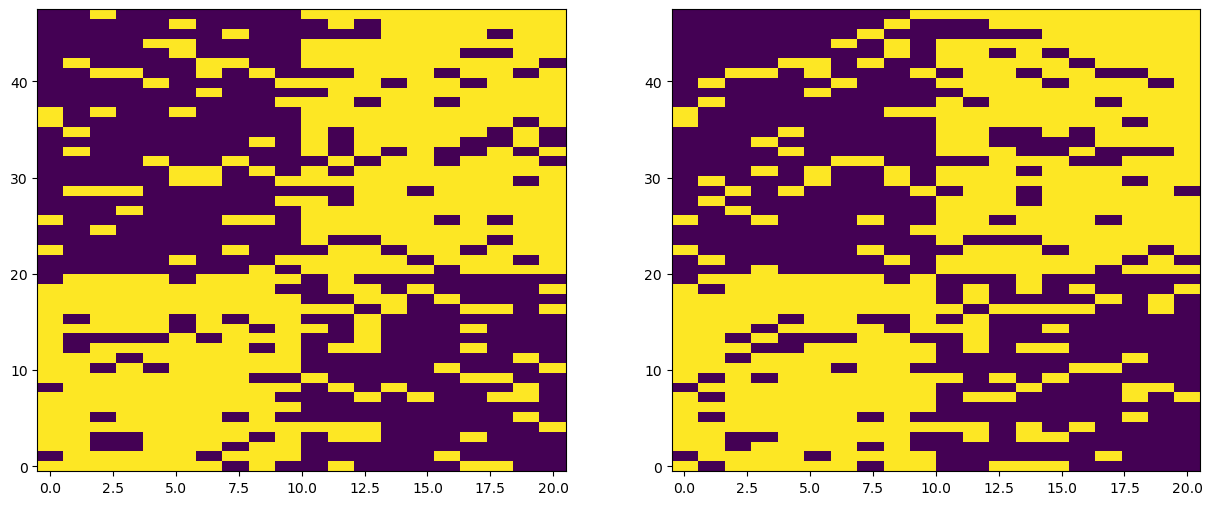

In [11]:
M = np.transpose(patterns)

fig, axs = plt.subplots(1,2, figsize=(15, 6))
ax1,ax2 = axs.flatten()

fma.plotting.plotColorMap(M, ax=ax1)

indices = np.lexsort(M)

M=M[:, indices]

print(M)

fma.plotting.plotColorMap(M, ax=ax2)


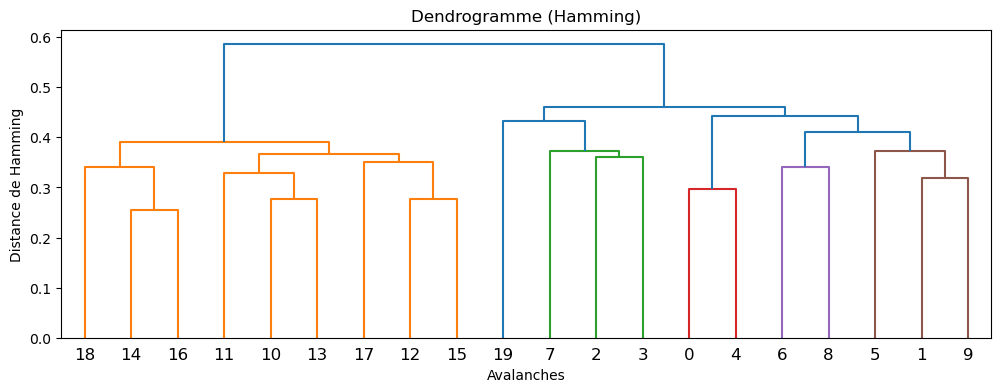

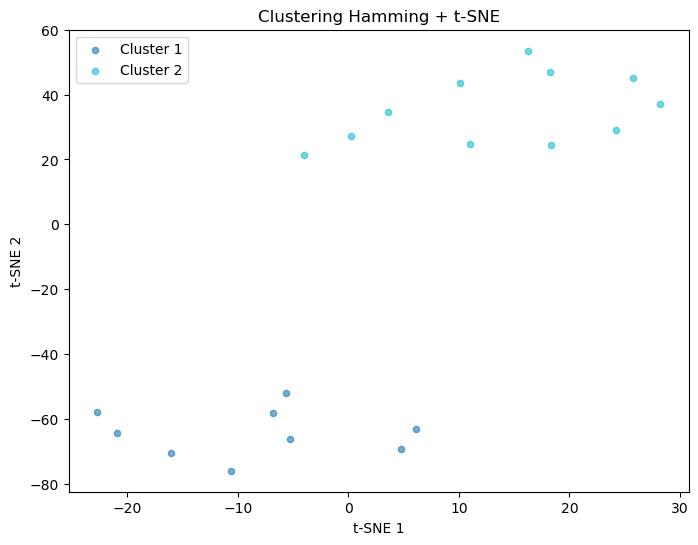

In [15]:
X = np.array(patterns)  # shape (n_avalanches, n_neurons)

# --- 1. Matrice de distances de Hamming ---
# pdist calcule toutes les paires de distances
hamming_distances = pdist(X, metric='hamming')
hamming_matrix = squareform(hamming_distances)  # shape (n_avalanches, n_avalanches)

# --- 2. Clustering hiérarchique sur Hamming ---
# 'ward' minimise la variance intra-cluster à chaque fusion
# autres options : 'average', 'complete', 'single'
linkage_matrix = linkage(hamming_distances, method='average')
n_clusters = 2  # à ajuster avec le dendrogramme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# optionnel : visualiser le dendrogramme pour choisir n_clusters
from scipy.cluster.hierarchy import dendrogram
fig_dend, ax_dend = plt.subplots(figsize=(12, 4))
dendrogram(linkage_matrix, ax=ax_dend, truncate_mode='lastp', p=20)
ax_dend.set_title('Dendrogramme (Hamming)')
ax_dend.set_xlabel('Avalanches')
ax_dend.set_ylabel('Distance de Hamming')
plt.show()

# --- 3. Réduction de dimension t-SNE ---
tsne = TSNE(
    n_components=2,
    metric='hamming',      # t-SNE utilise directement Hamming
    perplexity=min(50, len(X)//4),  # règle empirique : ~n_samples/4
    random_state=42,
    max_iter=1000
)
X_2d = tsne.fit_transform(X)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for k in range(1, n_clusters + 1):  # fcluster commence à 1
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors[k-1], label=f'Cluster {k}',
               alpha=0.6, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Clustering Hamming + t-SNE')
ax.legend()
plt.show()

[3 3 2 2 3 3 3 2 3 3 1 1 1 1 1 1 1 1 1 2]


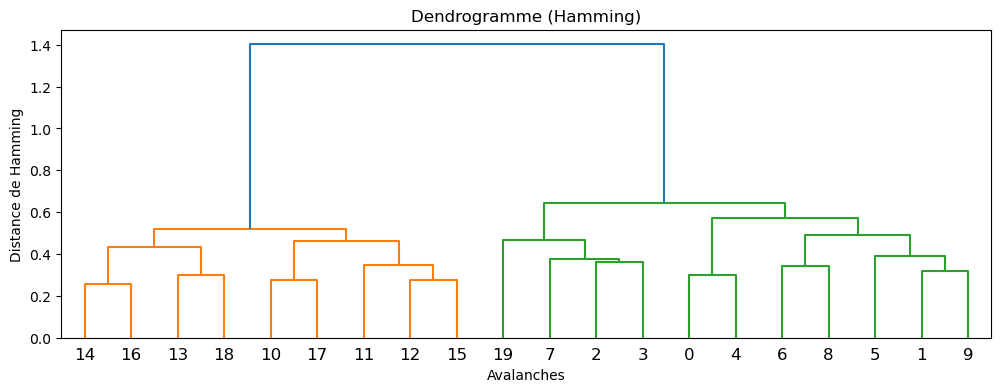

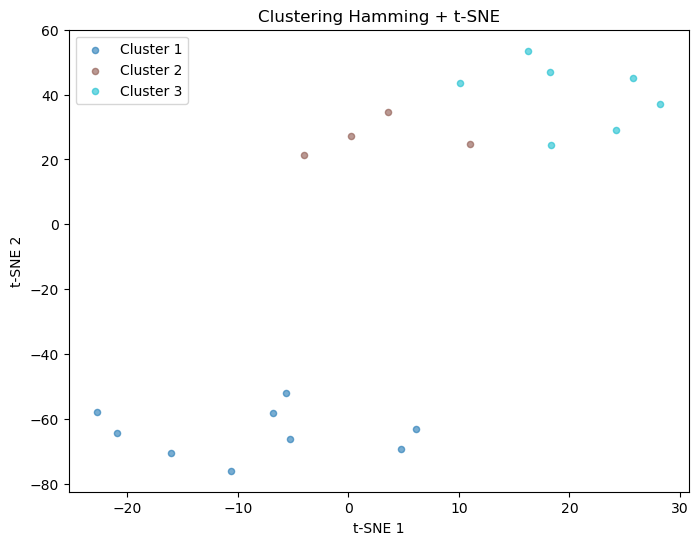

In [ ]:
X = np.array(patterns)  # shape (n_avalanches, n_neurons)

# --- 1. Matrice de distances de Hamming ---
# pdist calcule toutes les paires de distances
hamming_distances = pdist(X, metric='hamming')
hamming_matrix = squareform(hamming_distances)  # shape (n_avalanches, n_avalanches)

# --- 2. Clustering hiérarchique sur Hamming ---
# 'ward' minimise la variance intra-cluster à chaque fusion
# autres options : 'average', 'complete', 'single'
linkage_matrix = linkage(hamming_distances, method='ward')
n_clusters = 3  # à ajuster avec le dendrogramme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# optionnel : visualiser le dendrogramme pour choisir n_clusters
from scipy.cluster.hierarchy import dendrogram
fig_dend, ax_dend = plt.subplots(figsize=(12, 4))
dendrogram(linkage_matrix, ax=ax_dend, truncate_mode='lastp', p=20)
ax_dend.set_title('Dendrogramme (Hamming)')
ax_dend.set_xlabel('Avalanches')
ax_dend.set_ylabel('Distance de Hamming')
plt.show()

# --- 3. Réduction de dimension t-SNE ---
tsne = TSNE(
    n_components=2,
    metric='hamming',      # t-SNE utilise directement Hamming
    perplexity=min(50, len(X)//4),  # règle empirique : ~n_samples/4
    random_state=42,
    max_iter=1000
)
X_2d = tsne.fit_transform(X)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for k in range(1, n_clusters + 1):  # fcluster commence à 1
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors[k-1], label=f'Cluster {k}',
               alpha=0.6, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Clustering Hamming + t-SNE')
ax.legend()
plt.show()